<a href="https://colab.research.google.com/github/mikeogunmakin/study/blob/main/01%20Statistics/%20Causal%20Inference/Causal_Inference_in_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Causal Inference in Python


[link](https://www.amazon.co.uk/dp/1098140257/?bestFormat=true&k=causal%20inference%20in%20python&ref_=nb_sb_ss_w_scx-ent-bk-v2_k1_1_20_de&crid=2F6OD57MVNUZ9&sprefix=causal%20inference%20in%20) to resource.

## Chapter 1

### What is Causal Inference?

Association is when two quantities or random variables move together,
whereas causality is when change in one variable causes change in another.
<br>
<br>
Causal inference is
the science of inferring causation from association and understanding when and why
they differ

### Why We Do Causal Inference?

Generally speaking, you want to know cause-and-effect relationships so that you can
intervene on the cause to bring upon a desired effect.
<br>
<br>
If you take causal inference to the
industry, it becomes mostly a branch of the decision-making sciences. It stems from a desire to change something in your business or in your life so that
you can be better off.


### Machine Learning and Causal inference

The types of questions businesses want to answer with causal
inference are typically “what if ” type questions. Unfortunately,  machine learning (ML) is just awful at those types of questions. ML is very good at answering prediction questions.
<br>
<br>
You can do all sorts of
beautiful things with machine learning. The only requirement is to frame your prob‐
lems as prediction ones.
<br>
<br>
However, ML is not a panacea. It can perform wonders under rigid boundaries and
still fail miserably if its data deviates a little from what the model is accustomed to.
<br>
<br>
in many industries, low prices are
associated with low sales. For example, in the hotel industry, prices are low outside
the tourist season, and prices are high when demand is highest and hotels are full.
Given that data, a naive prediction might suggest that increasing the price would lead
to more rooms sold.
<br>
<br>
Machine learning uses associations between variables to predict one from the other. It
will work incredibly well as long as you don’t change the variables it is using to make
predictions. This completely defeats the purpose of using predictive ML for most
decision making that involves interventions.
<br>
<br>
One of the main goals of companies is to increase sales or usage.
Yet, an ML model that just predicts sales is oftentimes useless—if not harmful—for
this purpose. This model might even conclude something nonsensical, as in the
example where high volumes of sales are associated with high prices. Yet, you’d be
surprised by how many companies implement predictive ML models when the goal
they have in mind has nothing to do with predictions.
<br>
<br>
This does not mean that ML is completely useless for causal inference. It just means
that, when naively applied, it often does more harm than good.

### Association and Causation

Association is not causation. But sometimes, association is causation.
<br>
<br>
The unit of analysis in a causal inference study is usually the thing
you wish to intervene on (treat).
<br>
<br>
In most cases, the unit of analysis
will be people, as when you want to know the effect of a new product on customer retention. But it is not uncommon to have other
types of units. For instance, in this chapter’s example, the unit of
analysis is business. In this same example, you could also try to
answer when is the best moment to have sales, in which case the
unit of analysis would be a time period (week, in this case).

### The Treatment and the Outcome

The treatment for unit $i$, $T_i$, can be denoted as:
<br>
<br>

$$
T_i =
\begin{cases}
1 & \text{if unit } i \text{ received the treatment} \\
0 & \text{otherwise}
\end{cases}
$$

Treatment is essentially some intervention for which we want to know
the effect of.

Whereas, the varaible that we want to influence is the outcome. The outcome for unit $i$ can be denoted with $Y_i$.
<br>
<br>
the goal of causal inference as the process of
learning the impact $T$ has on $Y$.


### The Fundamental Problem of Causal Inference

The fundamental problem of causal inference is
that you can never observe the same unit with and without treatment.
<br>
<br>
The point is, you can only be certain about the true effect of a treatment on a unit if you could observe the unit, at the same time, with and without the
treatment.

### Causal Models

You can reason about causal problems intuitively, but if you want to go beyond sim‐
ple intuition, you need some formal notation.
<br>
<br>
A causal model is a series of assignment mechanisms denoted by <-
<br>
<br>
In these mecha‐
nisms, We use $u$ to denote variables outside the model, meaning we do not make a
statement about how they are generated. All the others are variables we care about are included in the model. Finally, there are functions $f$ that map
one variable to another.

Take the following causal model as an example:
<br>
<br>
$$
T \leftarrow f_t(u_t)
$$

$$
Y \leftarrow f_y(T, u_y)
$$
<br>
With the first equation, we're saying that $u_t$
, a set of variables we're not explicitly model‐
ing (also called exogenous variables), causes the treatment $T$ via the function $f_t$.
<br>
<br>
Next,
$T$ alongside another set of variables $u_y$
(which I’m also choosing not to model) jointly
causes the outcome $Y$ via the function $f_y$.
<br>
<br>
$u_y$
 is in this last equation to say that the
outcome is not determined by the treatment alone. Some other variables also play a
role in it, even if I’m choosing not to model them

Bringing this to the sales example,
it would mean that `weekly_amount_sold` is caused by the treatment `is_on_sale` and
other factors that are not specified, represented as $u$. The point of $u$ is to account for
all the variation in the variables caused by it that are not already accounted for by the
variables included in the model—also called endogenous variables.
<br>
<br>
In our example, I
could say that price drops are caused by factors—could be business size, could be
something else—that are not inside the model.

$$
IsOnSale ← f_t(u_t)
$$

$$
AmountSold ← f_y(IsOnSale, u_y)
$$

If you want to explicitly model more variables, you can take them out of u and
account for them in the model. For example, if we want to account for businesss size. We relegate it to the side with everything else in u. But we could model it explicitedly:

$$
\begin{aligned}
BusinessSize &\leftarrow f_s(u_s) \\[6pt]
IsOnSales &\leftarrow f_t(BusinessSize, u_t) \\[6pt]
AmountSold &\leftarrow f_y(IsOnSales, BusinessSize, u_y)
\end{aligned}
$$

To include this extra endogenous variable, first, I’m adding another equation to rep‐
resent how that variable came to be. Next, I’m taking BusinessSize out of $u_t$
. That is,
I’m no longer treating it as a variable outside the model. I’m explicitly saying that
$BusinessSize$ causes $IsOnSales$ (along with some other external factors that I’m still
choosing not to model). This is just a formal way of encoding the beliefs that bigger
businesses are more likely to cut prices.
<br>
<br>
Finally, I can also add $BusinessSize$ to the last
equation. This encodes the belief that bigger businesses also sell more. In other
words, BusinessSize is a common cause to both the treatment IsOnSales and the out‐
come AmountSold

### Interventions

Once you have a causal model you can intervene in hopes of answering causal questions.For example, you could take that very simple
causal model and force everyone to take the treatment t0
. This will eliminate the nat‐
ural causes of T, replacing them by a single constant:


“what would happen to
the outcome $Y$ if I were to set the treatment to $t_0$
?”


$$
T ← t_o
$$

$$
Y ← f_y(T, u_y)
$$

In the causal inference
literature, you can refer to these interventions with a $do(.)$ operator. If you want to
reason about what would happen if you intervene on $T$, you could write $do(T = t_o)$.


----
Quick Note on Expectation:



$$
E[X] = \text{population average of } X
$$

$$
E[Y \mid X=x] = \text{population average of } Y \text{ among those with } X=x
$$
<br>
<br>
Since we usually don't know the whole population, we use averages from our sample to estimate these values.
<br>
<br>
Example:
- $X$ = hours studied, $Y$ = exam score.
- $E[X]$ → average hours studied by everyone.
- $E[Y \mid X=2]$ → average exam score of people who study 2 hours.
-----


The $do(.)$ operator also gives you a first glance at why association is different from
causation.
<br>
<br>
how high sales volume for a business having a sale,
$E[AmountSold | IsOnSales = 1]$ , could overestimate the average sales volume a busi‐
ness would have had if it made a price cut, $E[AmountSold | do(IsOnSales) = 1]$ .
<br>
<br>
In the
first case, you are looking at businesses that chose to cut prices, which are probably
bigger businesses. In contrast, the latter refers to what would’ve happened if you forced every business to engage in sales, not just the big ones. Importantly, in general,
<br>
<br>
$$
E[AmountSold \mid IsOnSales = 1]
\neq
E[AmountSold \mid do(IsOnSales = 1)]
$$

One way to think about the difference between the two is in terms of selection and
intervention. When you condition on sales, you are measuring the amount sold on a
selected subsample of business that actually cut prices. When you condition on the
intervention do IsOnSales , you are forcing every business to cut prices and then
measuring the amount sold on the entire sample

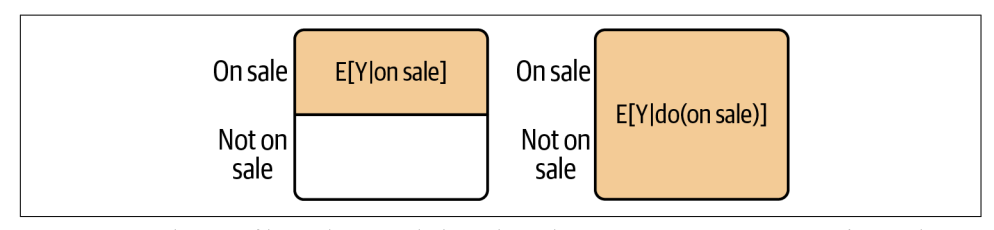

---
<br>

Quick Note on causal vs association quantities

<br>
A causal quantity describes an outcome under an intervention.

For example:
$$
E[AmountSold \mid do(IsOnSales = 1)]
$$

*"What would the average $Y$ be if we intervened and set $X=1$?"*
<br>
<br>

Whereas, an associational quantity describes a relationship between variables that you observe in the data, without intervening.

For example:

$$
E[Y \mid X = 1]
$$

The expected (average) value of \(Y\) among observations where \(X=1\).
<br>
<br>
$$
\begin{aligned}
E[Y \mid X=1] &\quad \rightarrow \quad \text{Associational quantity (observe)} \\[6pt]
E[Y \mid do(X=1)] &\quad \rightarrow \quad \text{Causal quantity (intervene)}
\end{aligned}
$$
<br>

---

$do(.)$ is used to define causal quantities that are not always recoverable from
observed data. In the previous example, you can’t observe $do(IsOnSales = 1)$ for every business, since you didn’t force them to do sales. $do(.)$ is most useful as a theoretical concept that you can use to explicitly state the causal qunatity you are after. Since it is
not directly observable, a lot of causal inference is about eliminating it from theoreti‐
cal expression—a process called identification.

### Individual Treatment Effect

The $do(.)$ operator also allows you to express the individual treatment effect, or the
impact of the treatment on the outcome for an individual unit $i$. You can write it as
the difference between two interventions:
<br>
<br>
$$
\tau_i = Y_i \mid do(T = t_1) - Y_i \mid do(T = t_0)
$$
<br>
In words, you would read this as “the effect, τ
i
, of going from treatment t0
to t1
for
unit i is the difference in the outcome of that unit under t1
 compared to t0
”. You could
use this to reason about our problem of figuring out the effect of flipping IsOnSales
from 0 to 1 in AmountSold:
<br>
<br>
$$
\tau_i
=
AmountSold_i \mid do(IsOnSales = 1)
-
AmountSold_i \mid do(IsOnSales = 0)
$$
<br>
Due to the fundamental problem of causal inference, you can only observe one term
of the preceding equation. So, even though you can theoretically express that quan‐
tity, it doesn’t necessarily mean you can recover it from data.


### Potential Outcomes

The potential outcomes framework describes what would happen to the same unit under different possible treatments.
<br>
<br>
For unit $i$, the potential outcome under treatment $t$ can be written as:




$$
Y_i(t) = Y_i \mid do(T_i=t)
$$

This means:

> **The outcome unit $i$ would have if its treatment were set to $t$.** You should read this as “unit i’s outcome would be Y if its treatment is set to $t$".

<br>

For a **binary treatment**, where:

$$
T_i \in \{0,1\}
$$

$t$ can take one of two values:

$$
Y_i(1) = \text{outcome for unit } i \text{ if treated}
$$

$$
Y_i(0) = \text{outcome for unit } i \text{ if not treated}
$$

Therefore:

- $t=1$ → **treated**
$$
Y_i(t) = Y_i \mid do(T_i=1)
$$

- $t=0$ → **not treated**

$$
Y_i(t) = Y_i \mid do(T_i=0)
$$


**Key idea:** Both potential outcomes conceptually exist for the same unit, but we can observe only **one** of them.

The outcome we observe is called the **factual outcome**.  
The outcome we do not observe is called the **counterfactual outcome**.
<br>
<br>
When talking about a binary treatment (treated or not treated), I’ll denote $Y_{0i}$
as the
potential outcome for unit $i$ without the treatment and $Y_{1i}$
 as the potential outcome
for the same unit i with the treatment.
<br>
<br>
I’ll also refer to one potential outcome as fac‐
tual, meaning I can observe it, and the other one as counterfactual, meaning it cannot
be observed. For example, if unit i is treated, I get to see what happens to it under the
treatment; that is, I get to see $Y_{1i}$
, which I’ll call the factual potential outcome. In con‐
trast, I can’t see what would happen if, instead, unit i wasn’t treated. That is, I can’t see
$Y_{0i}$
, since it is counterfactual:

$$
Y_i =
\begin{cases}
Y_{1i}, & \text{if unit } i \text{ received the treatment} \\[6pt]
Y_{0i}, & \text{otherwise}
\end{cases}
$$

The same relationship can also be written as:

$$
Y_i = T_iY_{1i} + (1-T_i)Y_{0i}
$$

or equivalently:

$$
Y_i = Y_{0i} + (Y_{1i}-Y_{0i})T_i
$$

Thus;

$$
Y_i = T_iY_{1i} + (1-T_i)Y_{0i} = Y_{0i} + (Y_{1i}-Y_{0i})T_i
$$



Quick Note on The Formula's:

The treatment variable $T_i$ acts like an **ON/OFF switch** that determines which potential outcome we actually observe.

For a binary treatment:

$$
T_i =
\begin{cases}
1, & \text{if unit } i \text{ is treated} \\
0, & \text{if unit } i \text{ is not treated}
\end{cases}
$$

Each unit $i$ has two potential outcomes:

$$
Y_{1i} = \text{outcome for unit } i \text{ if treated}
$$

$$
Y_{0i} = \text{outcome for unit } i \text{ if not treated}
$$

The observed outcome can therefore be written as:

$$
\boxed{Y_i = T_iY_{1i} + (1-T_i)Y_{0i}}
$$

Case 1: Unit $i$ is Treated

If $T_i=1$:

$$
Y_i = (1)Y_{1i} + (1-1)Y_{0i}
$$

$$
Y_i = Y_{1i} + 0
$$

$$
\boxed{Y_i = Y_{1i}}
$$

So $T_i=1$ **switches ON** the treated potential outcome $Y_{1i}$ and **switches OFF** the untreated potential outcome $Y_{0i}$.

Case 2: Unit $i$ is Not Treated

If $T_i=0$:

$$
Y_i = (0)Y_{1i} + (1-0)Y_{0i}
$$

$$
Y_i = 0 + Y_{0i}
$$

$$
\boxed{Y_i = Y_{0i}}
$$

So $T_i=0$ **switches OFF** the treated potential outcome $Y_{1i}$ and **switches ON** the untreated potential outcome $Y_{0i}$.

Therefore

The equation

$$
Y_i = T_iY_{1i} + (1-T_i)Y_{0i}
$$

is simply a mathematical way of writing:

$$
Y_i =
\begin{cases}
Y_{1i}, & T_i=1 \\
Y_{0i}, & T_i=0
\end{cases}
$$


Alternative Form

Starting with:

$$
Y_i = T_iY_{1i} + (1-T_i)Y_{0i}
$$

Expand the brackets:

$$
Y_i = T_iY_{1i} + Y_{0i} - T_iY_{0i}
$$

Rearrange:

$$
Y_i = Y_{0i} + T_iY_{1i} - T_iY_{0i}
$$

Factor out $T_i$:

$$
\boxed{Y_i = Y_{0i} + (Y_{1i}-Y_{0i})T_i}
$$

Interpretation

This equation can be understood as:

$$
\underbrace{Y_i}_{\text{Observed outcome}}
=
\underbrace{Y_{0i}}_{\text{Baseline outcome}}
+
\underbrace{(Y_{1i}-Y_{0i})}_{\text{Individual treatment effect}}
\underbrace{T_i}_{\text{ON/OFF switch}}
$$

In words:

> **Observed outcome = baseline outcome + treatment effect (if treated).**

If $T_i=0$:

$$
Y_i = Y_{0i}
$$

No treatment effect is added.

If $T_i=1$:

$$
Y_i = Y_{0i} + (Y_{1i}-Y_{0i}) = Y_{1i}
$$

The treatment effect is added to the baseline outcome.

Key Intuition

$$
\boxed{
Y_i = \text{Baseline} + \text{Treatment Effect} \times \text{Treatment Switch}
}
$$

So, $T_i$ determines **which of the two potential outcomes becomes the observed outcome**.
<br>

---

Back to our example, you can write $AmountSold_{0i}$
 to denote the amount business i
would have sold had it not done any price cut and $AmountSold_{1i}$
, the amount it
would have sold had it done sales. You can also define the effect in terms of these
potential outcomes:

$$
\tau_{i} = Y_{1i} - Y_{0i}
$$


Note: Causal inference is always
accompanied by assumptions. Assumptions are statements you
make when expressing a belief about how the data was generated.
The catch is that they usually can’t be verified with the data; that’s
why you need to assume them. Assumptions are not always easy to
spot.


### Consistency and Stable Unit Treatment Values

In the previous equations, there are two hidden assumptions.

- The first assumption
implies that the potential outcome is consistent with the treatment: $Y_{i}(t)$ = Y when
$T_i$ = t. In other words, there are no hidden multiple versions of the treatment beyond
the ones specified with $T$. This assumption can be violated if the treatment comes in multiple dosages, but you are onyl accounting for two of them; for example, if you care about the effect of discount coupons on sales and you treat it as being binary - customer a coupon or not- but in reality you tried multiple discount value uses. Inconsitency can also happen when treatment is ill defined. Imagine, for
example, trying to figure out the effect of receiving help from a financial planner in
one’s finances. What does “help” mean here? Is it a one-time consultation? Is it regu‐
lar advice and goal tracking? Bundling up all those flavors of financial advice into a
single category also violates the consistency assumption

- A second assumption that is implied is that of no interference, or stable unit of treat‐
ment value (SUTVA). That is, the effect of one unit is not influenced by the treatment
of other units. This assumption can be violated
if there are spillovers or network effects. For example, if you want to know the effect
of vaccines on preventing a contagious illness, vaccinating one person will make
other people close to her less likely to catch this illness, even if they themselves did
not get the treatment. Violations of this assumption usually cause us to think that the
effect is lower than it is. With spillover, control units get some treatment effect, which
in turn causes treatment and control to differ less sharply than if there was no
interference

Fortunately, you can often deal with violations on both assump‐
tions.

- To fix violations of consistency, you have to include all ver‐
sions of the treatment in your analysis.
- To deal with spillovers, you
can expand the definition of a treatment effect to include the effect
that comes from other units and use more flexible models to esti‐
mate those effects

### Causal Quantities of Interest

We can restate the fundamental problem of causal inference: you can never know the individual treatment effect
because you only observe one of the potential outcomes. Lets talk about the causal quantities we care about

**ATE (Average Treatment Effect)**

 Even though you can never know the individual effects, $\tau_i$
,
there are other interesting causal quantities that you can learn from data. For
instance, let’s define average treatment effect (ATE).
<br>
<br>
The average treatment effect represents the impact the treatment T would have
on average. Some units will be more impacted by it, some less, and you can never
know the individual impact on a unit. Lets define as follows:

$$
ATE = E[\tau_i]
$$

or

$$
ATE = E[Y_{1i} - Y_{0i}]
$$


or even,

$$
ATE = E[Y \mid do(T=1)] - E[Y \mid do(T=0)]
$$

Additionally, if you wanted to estimate the ATE
from data, you could replace the expectation with sample averages

$$
\frac{1}{N}\sum_{i=0}^{N}\tau_i
$$

or

$$
\frac{1}{N}\sum_{i=0}^{N}\left(Y_{1i} - Y_{0i}\right)
$$

Of course, in reality, due to the fundamental problem of causal inference, you can’t
actually do that, as only one of the potential outcomes will be observed for each unit.

**ATT (Average Treatment effect on the treated)**

This is the impact of the treatment on the units that got the treatment. For example, if
you did an offline marketing campaign in a city and you want to know how many
extra customers this campaign brought you in that city, this would be the ATT: the
effect of marketing on the city where the campaign was implemented.
<br>
<br>
Here, it’s
important to notice how both potential outcomes are defined for the same treatment.
In the case of the ATT, since you are conditioning on the treated, Y0i
is always
unobserved, but nonetheless well defined

$$
ATT = E[Y_{1i} - Y_{0i} \mid T=1]
$$

Essentially, ATT is the average treatment effect for a subset of the population: the units that actually received treatment.

**CATE (Conditional Average Treatment Effects)**

This is the effect in a group defined by the variable X.  For example, you might
want to know the effect of an email on customers that are older than 45 years and on
those that are younger than that. CATE is invaluable for personlization, since it allows you to know which type of unit responds better to
an intervention.

$$
CATE = E[Y_{1i} - Y_{0i} \mid X = x]
$$

Essentially, CATE is the Average treatment effect among the subset of people/units who have a particular characteristic \(X=x\).

----
---
Note: You can also define the previous quantities when the treatment is continuous. In this
case, you replace the difference with a partial derivative:

$$
\frac{\partial}{\partial t}E[Y_i(t)]
$$

This might seem fancy, but it’s just a way to say how much you expect E Yi
 to change
given a small increase in the treatment.

Previously, we considered a **binary treatment**:

$$
T \in \{0,1\}
$$

For example:

- $T=0$: no sale
- $T=1$: sale

With a binary treatment, we can express the individual causal effect as:

$$
\tau_i = Y_i(1) - Y_i(0)
$$

This compares the outcome for the same unit under treatment and without treatment.

---

Continuous Treatment

Sometimes the treatment is not simply ON or OFF. Instead, it can take many different values.

For example, suppose the treatment is the **discount percentage**:

$$
T = \text{discount percentage}
$$

The treatment could therefore be:

$$
T = 0\%, 5\%, 10\%, 15\%, 20\%, \ldots
$$

Suppose the outcome is:

$$
Y = \text{weekly amount sold}
$$

Instead of asking:

> What is the effect of treatment versus no treatment?

we can ask:

> If we increase the discount slightly, how much do we expect weekly sales to change?

This is represented using a derivative:

$$
\frac{\partial}{\partial t}E[Y_i(t)]
$$

The derivative tells us the **rate at which the expected outcome changes when we change the treatment**.

---

Example

Suppose the expected weekly amount sold is:

$$
E[Y_i(t)] = 100 + 3t
$$

where $t$ is the discount percentage.

For example:

$$
t=0 \Rightarrow E[Y_i(0)] = 100
$$

$$
t=10 \Rightarrow E[Y_i(10)] = 130
$$

$$
t=20 \Rightarrow E[Y_i(20)] = 160
$$

Now take the derivative with respect to treatment:

$$
\frac{\partial}{\partial t}E[Y_i(t)]
=
\frac{\partial}{\partial t}(100+3t)
=
3
$$

This means that increasing the discount by **1 percentage point** is expected to increase weekly sales by approximately **3 units**.

For example, increasing the discount from 10% to 11% gives:

$$
\Delta T = 11 - 10 = 1
$$

and therefore approximately:

$$
\Delta Y = 3
$$

additional units sold.

---

Intuition

For a binary treatment, we use a difference:

$$
Y_i(1)-Y_i(0)
$$

because there are only two treatment states.

For a continuous treatment, we use a derivative:

$$
\frac{\partial E[Y_i(t)]}{\partial t}
$$

because we want to know how quickly the outcome changes as the treatment changes.

Therefore:

$$
\boxed{
\frac{\partial E[Y_i(t)]}{\partial t}
=
\text{expected change in outcome per small change in treatment}
}
$$

You can think of the derivative as the **slope of the treatment-outcome relationship**.

----

### Causal Quantities: An Example

Turning back to our example.Let’s see how you can define these quantities in our business problem. First, notice
that you can never know the effect price cuts (having sales) have on an individual
business, as that would require you to see both potential outcomes, AmountSold0i
and AmountSold1i
, at the same time. But you could instead focus your attention on
something that is possible to estimate, like the average impact of price cuts on
amount sold:

Suppose:

- **Treatment $T$** = whether a business has a sale
- $T=1$ = sale
- $T=0$ = no sale
- **Outcome $Y$** = amount sold
- $Y_{0i}$ = amount business $i$ would sell **without a sale**
- $Y_{1i}$ = amount business $i$ would sell **with a sale**
- $X$ = weeks until Christmas

The individual treatment effect for business $i$ is:

$$
\tau_i = Y_{1i} - Y_{0i}
$$

The fundamental problem of causal inference is that, in reality, we cannot observe
both $Y_{1i}$ and $Y_{0i}$ for the same business at the same time.

---

1. Average Treatment Effect (ATE)

The **ATE** is the average causal effect of having a sale across **all businesses**.

$$
ATE = E[Y_{1i} - Y_{0i}]
$$

In words:

> On average, how much would having a sale change the amount sold across all businesses?

---

2. Average Treatment Effect on the Treated (ATT)

The **ATT** is the average causal effect specifically for businesses that
**actually had a sale**.

$$
ATT = E[Y_{1i} - Y_{0i} \mid T_i=1]
$$

In words:

> For businesses that actually had a sale, how much did the sale increase their sales on average?

---

3. Conditional Average Treatment Effect (CATE)

The **CATE** is the average causal effect for businesses with a particular
characteristic $X=x$.

For example:

$$
CATE(x)
=
E[Y_{1i} - Y_{0i} \mid X_i=x]
$$

If $X$ represents weeks until Christmas, then:

$$
CATE(X=0)
$$

means the average treatment effect **during Christmas week**, while:

$$
CATE(X=1)
$$

means the average treatment effect **one week before Christmas**.

---

Fantasy World: Both Potential Outcomes Are Observable

For the moment, suppose we have magical powers that allow us to observe both
potential outcomes for every business.

| $i$ | $Y_0$ | $Y_1$ | $T$ | $X$ | Observed $Y$ | Treatment Effect $\tau$ |
|---:|---:|---:|---:|---:|---:|---:|
| 1 | 200 | 220 | 0 | 0 | 200 | 20 |
| 2 | 120 | 140 | 0 | 0 | 120 | 20 |
| 3 | 300 | 400 | 0 | 1 | 300 | 100 |
| 4 | 450 | 500 | 1 | 0 | 500 | 50 |
| 5 | 600 | 600 | 1 | 0 | 600 | 0 |
| 6 | 600 | 800 | 1 | 1 | 800 | 200 |

Because we can see both $Y_0$ and $Y_1$, we can calculate the individual
treatment effect:

$$
\tau_i = Y_{1i}-Y_{0i}
$$

For example, for business 4:

$$
\tau_4 = 500-450=50
$$

So having a sale caused this business to sell **50 additional units**.

---

Calculating the ATE

The individual treatment effects are:

$$
20,\;20,\;100,\;50,\;0,\;200
$$

Therefore:

$$
ATE
=
\frac{20+20+100+50+0+200}{6}
$$

$$
\boxed{ATE=65}
$$

Interpretation

Across all six businesses, having a sale increases the amount sold by:

$$
\boxed{65\text{ units on average}}
$$

---

Calculating the ATT

ATT only considers businesses that were **actually treated**:

$$
T=1
$$

These are businesses 4, 5, and 6.

Their treatment effects are:

$$
50,\;0,\;200
$$

Therefore:

$$
ATT
=
\frac{50+0+200}{3}
$$

$$
\boxed{ATT=83.33}
$$

Interpretation

Among businesses that **actually chose to have a sale**, the sale increased the
amount sold by approximately:

$$
\boxed{83.33\text{ units on average}}
$$

Notice that:

$$
ATE \neq ATT
$$

because the businesses that received treatment may be different from the overall
population of businesses.

---

Calculating CATE

Now suppose we want to know whether the effectiveness of a sale depends on how
close we are to Christmas.

One week before Christmas: $X=1$

Businesses 3 and 6 have:

$$
X=1
$$

Their treatment effects are:

$$
100,\;200
$$

Therefore:

$$
CATE(X=1)
=
\frac{100+200}{2}
$$

$$
\boxed{CATE(X=1)=150}
$$

So one week before Christmas, having a sale increases sales by approximately:

$$
\boxed{150\text{ units}}
$$

on average.

---

Christmas week: $X=0$

Businesses 1, 2, 4, and 5 have:

$$
X=0
$$

Their treatment effects are:

$$
20,\;20,\;50,\;0
$$

Therefore:

$$
CATE(X=0)
=
\frac{20+20+50+0}{4}
$$

$$
\boxed{CATE(X=0)=22.5}
$$

So during Christmas week, having a sale increases sales by only:

$$
\boxed{22.5\text{ units}}
$$

on average.

Therefore:

$$
CATE(X=1)=150
$$

while:

$$
CATE(X=0)=22.5
$$

This suggests that businesses benefit much more from price cuts **one week before
Christmas** than during Christmas week itself.

---

Back to Reality: The Fundamental Problem of Causal Inference

Unfortunately, in reality we cannot observe both potential outcomes.

For an untreated business ($T=0$), we observe:

$$
Y_0
$$

but we cannot observe:

$$
Y_1
$$

For a treated business ($T=1$), we observe:

$$
Y_1
$$

but we cannot observe:

$$
Y_0
$$

Therefore, the real dataset looks like:

| $i$ | $Y_0$ | $Y_1$ | $T$ | $X$ | Observed $Y$ |
|---:|---:|---:|---:|---:|---:|
| 1 | 200 | ? | 0 | 0 | 200 |
| 2 | 120 | ? | 0 | 0 | 120 |
| 3 | 300 | ? | 0 | 1 | 300 |
| 4 | ? | 500 | 1 | 0 | 500 |
| 5 | ? | 600 | 1 | 0 | 600 |
| 6 | ? | 800 | 1 | 1 | 800 |

Because one potential outcome is missing for every business, we cannot directly
calculate:

$$
\tau_i = Y_{1i}-Y_{0i}
$$

This is why causal inference can be thought of as a **missing-data problem**.

---

Why Can't We Just Compare Treated and Untreated Businesses?

A tempting approach would be to calculate:

$$
E[Y\mid T=1]-E[Y\mid T=0]
$$

The average observed outcome for the treated businesses is:

$$
E[Y\mid T=1]
=
\frac{500+600+800}{3}
=
633.33
$$

The average observed outcome for the untreated businesses is:

$$
E[Y\mid T=0]
=
\frac{200+120+300}{3}
=
206.67
$$

Therefore:

$$
633.33-206.67
=
\boxed{426.67}
$$

But we already know from our fantasy dataset that:

$$
ATE=65
$$

So:

$$
\boxed{426.67 \neq 65}
$$

Why is the naive comparison so wrong?

---

Association Is Not Causation

The problem is that businesses that chose to have sales were already different
from businesses that did not.

Look at the potential outcome **without treatment**, $Y_0$.

For the treated businesses:

$$
Y_0 = 450,\;600,\;600
$$

Even **without having a sale**, these businesses would have sold a lot.

For the untreated businesses:

$$
Y_0 = 200,\;120,\;300
$$

These businesses naturally sell less.

Therefore, comparing:

$$
E[Y\mid T=1]
$$

with:

$$
E[Y\mid T=0]
$$

mixes together two things:

1. The actual **causal effect of having a sale**
2. Pre-existing differences between businesses that have sales and businesses that do not

Therefore:

$$
\boxed{
E[Y\mid T=1]-E[Y\mid T=0]
\neq
ATE
}
$$

in general.

---
 Key Takeaway

ATE

Average causal effect across **everyone**:

$$
\boxed{
ATE=E[Y_1-Y_0]
}
$$

ATT

Average causal effect among the **treated population**:

$$
\boxed{
ATT=E[Y_1-Y_0\mid T=1]
}
$$

CATE

Average causal effect for units with a particular characteristic:

$$
\boxed{
CATE(x)=E[Y_1-Y_0\mid X=x]
}
$$

For this example:

$$
ATE=65
$$

$$
ATT=83.33
$$

$$
CATE(X=1)=150
$$

$$
CATE(X=0)=22.5
$$

The central problem is that in real life we never observe both:

$$
Y_0 \quad \text{and} \quad Y_1
$$

for the same unit.

Therefore, causal inference is fundamentally about finding credible ways to
estimate the **missing counterfactual outcome**.

Most importantly:

$$
\boxed{
\text{Difference in observed groups}
\neq
\text{causal treatment effect}
}
$$

unless we have additional assumptions or an experimental design that allows the
observed comparison to identify the causal effect.